# **House Prices - Advanced Regression Techniques**

## 概要
住宅のあらゆる側面を説明する79の説明変数を用いて、各住宅の販売価格を予測する。

## 事前準備

### ライブラリのインストール

In [82]:
!pip install optuna -q

### ライブラリのインポート

In [83]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import skew
from scipy.special import boxcox1p
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import RobustScaler
import optuna

### データファイルのアップロード

In [84]:
uploaded = files.upload()

## EDA（探索的データ分析）

### 特徴量一覧

**住宅基本情報**
| カラム名 | 説明 |
|---|---|
| Id | 物件ID |
| MSSubClass | 住宅タイプ（数値コード） |
| MSZoning | 用途地域 |
| LotFrontage | 道路に面した長さ（フィート） |
| LotArea | 敷地面積（平方フィート） |
| Street | 道路の種類 |
| Alley | 路地アクセスの種類 |
| LotShape | 土地の形状 |
| LandContour | 土地の平坦度 |
| Utilities | 利用可能なインフラ |
| LotConfig | 土地の配置 |
| LandSlope | 土地の傾斜 |
| Neighborhood | 地域名 |
| Condition1 | 主要道路・線路との位置関係 |
| Condition2 | 主要道路・線路との位置関係（2つ目） |

**建物基本情報**
| カラム名 | 説明 |
|---|---|
| BldgType | 建物タイプ |
| HouseStyle | 住宅スタイル |
| OverallQual | 総合品質（1〜10） |
| OverallCond | 総合状態（1〜10） |
| YearBuilt | 建築年 |
| YearRemodAdd | リフォーム年 |
| RoofStyle | 屋根スタイル |
| RoofMatl | 屋根素材 |
| Exterior1st | 外壁素材1 |
| Exterior2nd | 外壁素材2 |
| MasVnrType | 石積みベニヤの種類 |
| MasVnrArea | 石積みベニヤの面積 |
| ExterQual | 外壁品質 |
| ExterCond | 外壁状態 |
| Foundation | 基礎の種類 |

**地下室**
| カラム名 | 説明 |
|---|---|
| BsmtQual | 地下室品質 |
| BsmtCond | 地下室状態 |
| BsmtExposure | 地下室の採光 |
| BsmtFinType1 | 地下室仕上げタイプ1 |
| BsmtFinSF1 | 地下室仕上げ面積1 |
| BsmtFinType2 | 地下室仕上げタイプ2 |
| BsmtFinSF2 | 地下室仕上げ面積2 |
| BsmtUnfSF | 地下室未仕上げ面積 |
| TotalBsmtSF | 地下室合計面積 |
| BsmtFullBath | 地下室フルバス数 |
| BsmtHalfBath | 地下室ハーフバス数 |

**設備**
| カラム名 | 説明 |
|---|---|
| Heating | 暖房タイプ |
| HeatingQC | 暖房品質 |
| CentralAir | セントラルエアコン有無 |
| Electrical | 電気設備タイプ |

**居住スペース**
| カラム名 | 説明 |
|---|---|
| 1stFlrSF | 1階面積 |
| 2ndFlrSF | 2階面積 |
| LowQualFinSF | 低品質仕上げ面積 |
| GrLivArea | 地上居住面積 |
| FullBath | フルバス数 |
| HalfBath | ハーフバス数 |
| BedroomAbvGr | 寝室数 |
| KitchenAbvGr | キッチン数 |
| KitchenQual | キッチン品質 |
| TotRmsAbvGrd | 総部屋数（バス除く） |
| Functional | 住宅機能性 |
| Fireplaces | 暖炉数 |
| FireplaceQu | 暖炉品質 |

**ガレージ**
| カラム名 | 説明 |
|---|---|
| GarageType | ガレージタイプ |
| GarageYrBlt | ガレージ建築年 |
| GarageFinish | ガレージ仕上げ |
| GarageCars | ガレージ収容台数 |
| GarageArea | ガレージ面積 |
| GarageQual | ガレージ品質 |
| GarageCond | ガレージ状態 |
| PavedDrive | 舗装ドライブウェイ有無 |

**屋外スペース**
| カラム名 | 説明 |
|---|---|
| WoodDeckSF | ウッドデッキ面積 |
| OpenPorchSF | オープンポーチ面積 |
| EnclosedPorch | 囲いポーチ面積 |
| 3SsnPorch | 3シーズンポーチ面積 |
| ScreenPorch | スクリーンポーチ面積 |
| PoolArea | プール面積 |
| PoolQC | プール品質 |
| Fence | フェンス品質 |
| MiscFeature | その他設備 |
| MiscVal | その他設備の価値 |

**売却情報**
| カラム名 | 説明 |
|---|---|
| MoSold | 売却月 |
| YrSold | 売却年 |
| SaleType | 売却タイプ |
| SaleCondition | 売却条件 |
| SalePrice | 売却価格（目的変数） |

### 確認項目

・データの行数・列数  
・各列のデータ型と欠損数  
・数値列の統計量  
・カテゴリ列のユニーク値・最頻値  
・欠損値が多い列の把握  

In [85]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(train.info())
print(train.describe())
print(train.describe(include='object'))

missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

## 前処理

### 欠損値の処理

「ない」という情報自体に意味があるものは、推定値を補完しない。  
質的変数 → noneを入れる  
量的変数 → 0を入れる

`Electrical`は、欠損が1件のみであり記録漏れの可能性が高いため、最頻値で補完する。  
`LotFrontage`は、地形などによって値が変わる可能性が高いと推測し、`Neighborhood`でグルーピングをし、各グループの平均値を補完する。

In [86]:
none_cols = ['PoolQC',
             'MiscFeature',
             'Alley',
             'Fence',
             'FireplaceQu',
             'GarageType',
             'GarageFinish',
             'GarageQual',
             'GarageCond',
             'BsmtQual',
             'BsmtCond',
             'BsmtExposure',
             'BsmtFinType1',
             'BsmtFinType2',
             'MasVnrType']
zero_cols = ['GarageYrBlt',
             'GarageArea',
             'GarageCars',
             'BsmtFinSF1',
             'BsmtFinSF2',
             'BsmtUnfSF',
             'TotalBsmtSF',
             'BsmtFullBath',
             'BsmtHalfBath',
             'MasVnrArea']

for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

for col in zero_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))
test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
12


In [87]:
missing = test.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

MSZoning       4
Utilities      2
Functional     2
Exterior1st    1
Exterior2nd    1
KitchenQual    1
SaleType       1
dtype: int64


In [88]:
cols = ['MSZoning',
        'Utilities',
        'Functional',
        'Exterior1st',
        'Exterior2nd',
        'KitchenQual',
        'SaleType']

for col in cols:
    test[col] = test[col].fillna(test[col].mode()[0])

print(test.isnull().sum().sum())

0


### log変換

目的変数の分布が左に偏っており、線形回帰系のモデルを扱うのが難しくなってしまうため、対数をとり正規分布に近づける処理を行う。

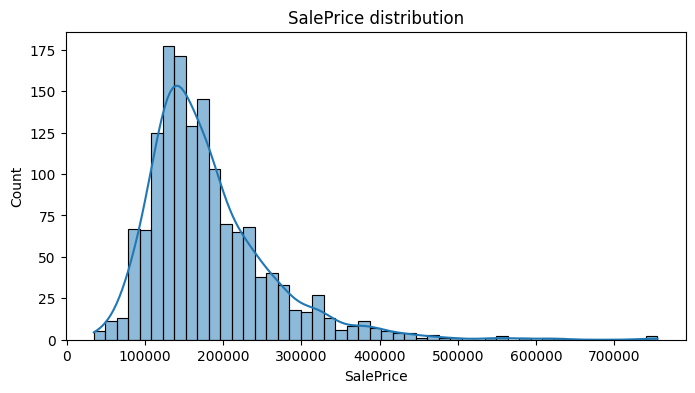

In [89]:
plt.figure(figsize=(8, 4))
sns.histplot(train['SalePrice'], kde=True)
plt.title('SalePrice distribution')
plt.show()

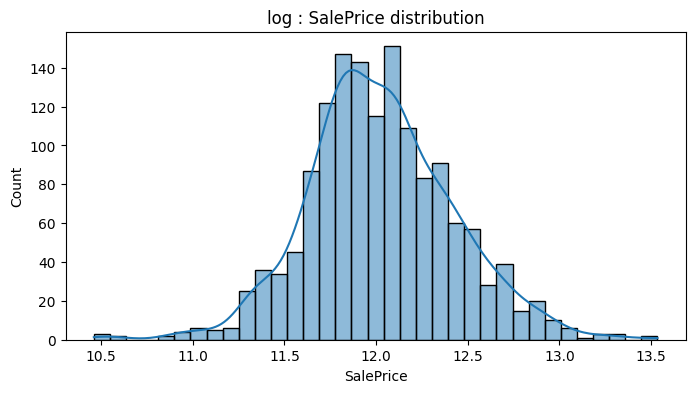

In [90]:
train['SalePrice'] = np.log1p(train['SalePrice'])

plt.figure(figsize=(8, 4))
sns.histplot(train['SalePrice'], kde=True)
plt.title('log : SalePrice distribution')
plt.show()

## 特徴量エンジニアリング

### 質的変数（カテゴリ変数）のエンコーディング

ラベルエンコーディング：順序に意味があるカテゴリ変数  
ワンホットエンコーディング：順序のないカテゴリ変数

In [91]:
for col in train.select_dtypes(include='object').columns:
    print(f"{col}: {train[col].unique()}")

MSZoning: ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street: ['Pave' 'Grvl']
Alley: ['None' 'Grvl' 'Pave']
LotShape: ['Reg' 'IR1' 'IR2' 'IR3']
LandContour: ['Lvl' 'Bnk' 'Low' 'HLS']
Utilities: ['AllPub' 'NoSeWa']
LotConfig: ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope: ['Gtl' 'Mod' 'Sev']
Neighborhood: ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Condition1: ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Condition2: ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
BldgType: ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle: ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle: ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
RoofMatl: ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
 'ClyTile']
Exterior1st: [

In [92]:
ordinal_cols = {
    'ExterQual':    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'ExterCond':    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual':     ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtCond':     ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'HeatingQC':    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual':  ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'FireplaceQu':  ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageQual':   ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageCond':   ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'PoolQC':       ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtExposure': ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFinType1': ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFinType2': ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'GarageFinish': ['None', 'Unf', 'RFn', 'Fin'],
    'LandSlope':    ['Gtl', 'Mod', 'Sev'],
    'Functional':   ['Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev'],
    'PavedDrive':   ['N', 'P', 'Y'],
    'Fence':        ['None', 'MnWw', 'MnPrv', 'GdWo', 'GdPrv'],
}

for col, order in ordinal_cols.items():
    enc = OrdinalEncoder(categories=[order])
    train[col] = enc.fit_transform(train[[col]])
    test[col]  = enc.transform(test[[col]])

print(train['ExterQual'].unique())

[3. 2. 4. 1.]


In [93]:
train = pd.get_dummies(train)
test  = pd.get_dummies(test)

train, test = train.align(test, join='left', axis=1, fill_value=0)

print(train.shape)
print(test.shape)

(1460, 231)
(1459, 231)


## モデル比較

### 線形回帰

In [94]:
X = train.drop(columns=['SalePrice'])
y = train['SalePrice']

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"RMSE: {-scores.mean():.4f} ± {scores.std():.4f}")


RMSE: 0.1521 ± 0.0260


### XGBoost

In [95]:
model_xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)

scores_xgb = cross_val_score(model_xgb, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"XGBoost RMSE: {-scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")

XGBoost RMSE: 0.1323 ± 0.0120


### LightGBM

In [96]:
model_lgb = LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)

scores_lgb = cross_val_score(model_lgb, X, y, cv=5, scoring='neg_root_mean_squared_error')

In [97]:
print(f"LightGBM RMSE: {-scores_lgb.mean():.4f} ± {scores_lgb.std():.4f}")

LightGBM RMSE: 0.1302 ± 0.0099


### LightGBM + 特徴量追加
`TotalSF` `HouseAge`の2つの特徴量を追加する。

In [98]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

In [99]:
X = train.drop(columns=['SalePrice'])
y = train['SalePrice']

scores_lgb2 = cross_val_score(model_lgb, X, y, cv=5, scoring='neg_root_mean_squared_error')

In [100]:
print(f"LightGBM + 特徴量追加 RMSE: {-scores_lgb2.mean():.4f} ± {scores_lgb2.std():.4f}")

LightGBM + 特徴量追加 RMSE: 0.1318 ± 0.0088


### LightGBM + 特徴量追加 + 不要列削除

結果に影響を及ぼさないと考えられる変数や、逆影響を及ぼす可能性がある変数を削除する。

In [101]:
model_lgb.fit(X, y)

importances = pd.Series(model_lgb.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

pd.set_option('display.max_rows', None)
print(importances_sorted)

GrLivArea                1938
Id                       1742
LotArea                  1727
TotalSF                  1660
1stFlrSF                 1351
OpenPorchSF              1281
BsmtUnfSF                1242
GarageArea               1237
LotFrontage              1176
TotalBsmtSF              1158
BsmtFinSF1               1029
MasVnrArea                930
HouseAge                  809
YearRemodAdd              707
GarageYrBlt               706
EnclosedPorch             704
MoSold                    690
WoodDeckSF                629
Neighborhood_IDOTRR       570
OverallCond               538
OverallQual               473
2ndFlrSF                  453
YearBuilt                 444
YrSold                    395
TotRmsAbvGrd              257
SaleCondition_Normal      245
MSSubClass                209
BsmtFinSF2                204
BsmtFinType1              202
BsmtExposure              200
ExterCond                 194
HeatingQC                 191
KitchenQual               165
FireplaceQ

In [102]:
cols_to_drop = ['Id', 'SalePrice']

zero_importance_cols = importances[importances == 0].index.tolist()
cols_to_drop.extend(zero_importance_cols)

X = train.drop(columns=['SalePrice'] + [c for c in cols_to_drop if c != 'SalePrice'])
y = train['SalePrice']
X_test = test.drop(columns=cols_to_drop)

print(X.shape)
print(X_test.shape)

(1460, 141)
(1459, 141)


In [103]:
scores_lgb3 = cross_val_score(model_lgb, X, y, cv=5, scoring='neg_root_mean_squared_error')

In [104]:
print(f"LightGBM 不要列削除後 RMSE: {-scores_lgb3.mean():.4f} ± {scores_lgb3.std():.4f}")

LightGBM 不要列削除後 RMSE: 0.1318 ± 0.0088


### XGBoost + LightGBM アンサンブル

In [105]:
model_xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
model_lgb = LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)

model_xgb.fit(X, y)
model_lgb.fit(X, y)

from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_xgb.fit(X_tr, y_tr)
    model_lgb.fit(X_tr, y_tr)

    oof_xgb[val_idx] = model_xgb.predict(X_val)
    oof_lgb[val_idx] = model_lgb.predict(X_val)

oof_ensemble = (oof_xgb + oof_lgb) / 2

rmse = np.sqrt(mean_squared_error(y, oof_ensemble))

In [106]:
print(f"Ensemble RMSE: {rmse:.4f}")

Ensemble RMSE: 0.1357


### 考察

LightGBM単体での結果が最もよく、特徴量追加や列削除は効果がなかった。XGBoostは単体での結果がよくなく、LightGBMとのアンサンブルを試したが、それぞれの単体の結果より悪化してしまった。そこで、LightGBMの精度をより高めるため、ハイパーパラメータチューニングを実施することとした。



### LightGBM + チューニング

In [107]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'verbose': -1
    }
    model = LGBMRegressor(**params)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=100)

[I 2026-03-24 11:48:55,196] A new study created in memory with name: no-name-7a4b41b7-9517-4258-b69b-291fe4330964
[I 2026-03-24 11:48:57,709] Trial 0 finished with value: 0.1344260581999847 and parameters: {'n_estimators': 1197, 'learning_rate': 0.07334791680696877, 'max_depth': 3, 'num_leaves': 26, 'min_child_samples': 9, 'subsample': 0.8011357390092181, 'colsample_bytree': 0.6708997092244249}. Best is trial 0 with value: 0.1344260581999847.
[I 2026-03-24 11:49:17,863] Trial 1 finished with value: 0.1372986627026679 and parameters: {'n_estimators': 2370, 'learning_rate': 0.09427244428214565, 'max_depth': 8, 'num_leaves': 48, 'min_child_samples': 9, 'subsample': 0.9737995292269721, 'colsample_bytree': 0.9232024430111085}. Best is trial 0 with value: 0.1344260581999847.
[I 2026-03-24 11:49:34,902] Trial 2 finished with value: 0.13647200578523352 and parameters: {'n_estimators': 2750, 'learning_rate': 0.04664187036887486, 'max_depth': 10, 'num_leaves': 118, 'min_child_samples': 25, 'subs

In [108]:
print(f'LightGBM Best RMSE: {study_lgb.best_value:.5f}')
print(f'LightGBM Best params: {study_lgb.best_params}')

LightGBM Best RMSE: 0.12653
LightGBM Best params: {'n_estimators': 636, 'learning_rate': 0.024433776374427955, 'max_depth': 4, 'num_leaves': 44, 'min_child_samples': 23, 'subsample': 0.8857464771488573, 'colsample_bytree': 0.6549764243749302}


### XGBoost + チューニング

In [109]:
def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'random_state': 42,
        'verbosity': 0
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=100)

[I 2026-03-24 11:55:43,675] A new study created in memory with name: no-name-f9eaee47-83fe-451e-9891-a760f7fbc7dc
[I 2026-03-24 11:56:08,903] Trial 0 finished with value: 0.1322107517294786 and parameters: {'n_estimators': 1764, 'learning_rate': 0.0869630964157811, 'max_depth': 5, 'min_child_weight': 1, 'subsample': 0.8704742890166348, 'colsample_bytree': 0.8495421719460984, 'reg_alpha': 0.03123019540983008, 'reg_lambda': 0.04901158218583042}. Best is trial 0 with value: 0.1322107517294786.
[I 2026-03-24 11:56:38,954] Trial 1 finished with value: 0.13418327227500768 and parameters: {'n_estimators': 1875, 'learning_rate': 0.09991661002448256, 'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.6226160309513, 'colsample_bytree': 0.9908889289264748, 'reg_alpha': 0.04948635016299167, 'reg_lambda': 0.023277250920640542}. Best is trial 0 with value: 0.1322107517294786.
[I 2026-03-24 11:57:04,979] Trial 2 finished with value: 0.1349350906332019 and parameters: {'n_estimators': 2487, 'learni

In [110]:
print(f'XGBoost Best RMSE: {study_xgb.best_value:.5f}')
print(f'XGBoost Best params: {study_xgb.best_params}')

XGBoost Best RMSE: 0.12510
XGBoost Best params: {'n_estimators': 586, 'learning_rate': 0.032200739116384526, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.7244054547607067, 'colsample_bytree': 0.5415154707495766, 'reg_alpha': 0.31309556175310654, 'reg_lambda': 0.1605318855935472}


## 提出

In [116]:
model_lgb = LGBMRegressor(**study_lgb.best_params, random_state=42, verbose=-1)
model_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, verbosity=0)

model_lgb.fit(X, y)
model_xgb.fit(X, y)

pred = np.expm1(
    0.2 * model_lgb.predict(X_test) +
    0.8 * model_xgb.predict(X_test)
)

submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': pred})
submission.to_csv('submission.csv', index=False)

## まとめ

### 欠損値処理

欠損値の意味を考慮して補完方法を使い分けた。
- `PoolQC`, `FireplaceQu` など設備系 → `'None'`（設備がない）
- `GarageArea`, `BsmtFinSF1` など面積系 → `0`（同上）
- `LotFrontage` → Neighborhoodごとの中央値（地域差を考慮）
- その他カテゴリ系 → 最頻値

### エンコーディング
- 順序のあるカテゴリ（`ExterQual`, `BsmtQual` など）→ `OrdinalEncoder` で順序を明示的に指定
- その他カテゴリ → `get_dummies` でOne-Hot

### 特徴量エンジニアリング

| 特徴量 | 内容 |
|---|---|
| `TotalSF` | 地下＋1F＋2F の合計面積 |
| `HouseAge` | 売却年 − 建築年 |

シンプルな2特徴量に絞ったことでノイズを抑え、モデルの汎化性能を高めた。
特徴量を増やしすぎるとCVスコアが悪化することを実験的に確認し、質より量の方針とした。

### 結果

| 指標 | スコア |
|---|---|
| Public Score | **0.12222** |

### 考察

- 特徴量は1個ずつ追加してCVスコアへの影響を検証すべき（一括追加するとどれが効いたか分からなくなる）
- 線形モデルはこのデータとの相性が悪く、アンサンブルに入れると足を引っ張った
- データリーク（重要度ゼロの特徴量削除、LotFrontageの補完）は今回は許容したが、厳密なコンペでは対策が必要